In [2]:
import pandas as pd

df = pd.read_csv("../data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
# Remove target column (IMPORTANT)
X = df.drop(columns=["DEATH_EVENT"])

# Normalize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

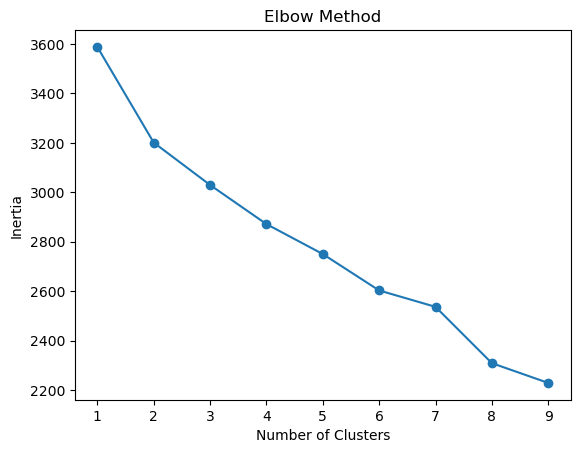

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [7]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

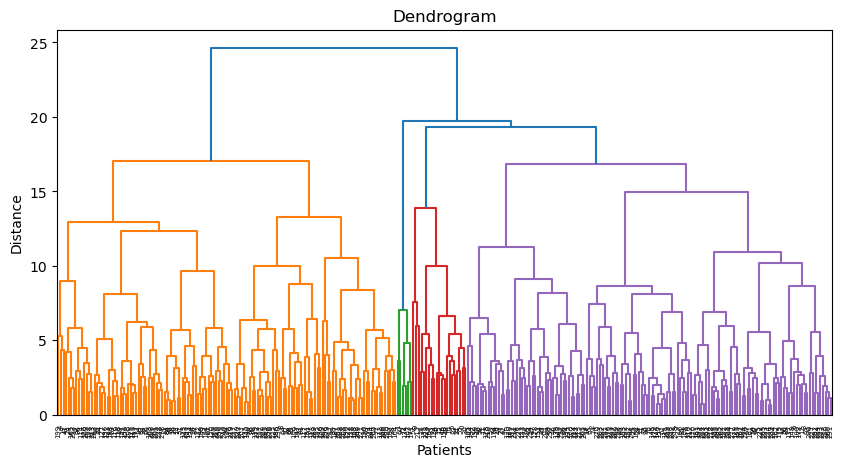

In [8]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Patients')
plt.ylabel('Distance')
plt.show()

In [9]:
# K-Means
kmeans_summary = df.groupby('KMeans_Cluster').mean()
print(kmeans_summary)

# Hierarchical
hc_summary = df.groupby('Hierarchical_Cluster').mean()
print(hc_summary)

                      age   anaemia  creatinine_phosphokinase  diabetes  \
KMeans_Cluster                                                            
0               61.406250  0.335938                644.429688  0.210938   
1               63.752941  0.623529                389.800000  0.164706   
2               57.096907  0.383721                678.488372  0.976744   

                ejection_fraction  high_blood_pressure      platelets  \
KMeans_Cluster                                                          
0                       34.773438             0.273438  250020.737422   
1                       45.376471             0.529412  264876.543647   
2                       35.802326             0.290698  281708.025000   

                serum_creatinine  serum_sodium       sex   smoking  \
KMeans_Cluster                                                       
0                       1.434375    136.203125  1.000000  0.703125   
1                       1.228824    138.305882  

In [10]:
df.groupby('KMeans_Cluster').mean()
df.groupby('Hierarchical_Cluster').mean()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,KMeans_Cluster
Hierarchical_Cluster,,,,,,,,,,,,,,
0,61.818932,0.462963,424.055556,0.320988,37.364198,0.370370,244983.928148,1.529753,136.654321,0.969136,0.543210,129.629630,0.339506,0.438272
1,59.653947,0.412214,535.213740,0.549618,39.167939,0.335878,285330.506565,1.242519,136.557252,0.236641,0.030534,133.358779,0.290076,1.404580
2,60.000000,0.000000,5860.000000,0.166667,33.833333,0.166667,279726.338333,1.030000,137.333333,1.000000,0.666667,79.666667,0.500000,0.333333
